# Instructor Effectiveness Modeling — EdTech Case Study
(no LLMs, no external data, no AutoML)

Name:Koustubh Satishrao Kotgire
Email:koustubhkodgire12@gmail.com
Phone No:7276314879
linkdin: www.linkedin.com/in/koustubhkotgire
### Contents
0. Setup & data loading  
1. Exploratory Data Analysis  
2. Defining Instructor Effectiveness  
3. Aggregating to instructor level  
4. Model building  
5. Model evaluation  
6. Interpretation & product use  
7. Mandatory analysis questions  
8. Limitations, ethics & next steps

## 0. Setup & Data Loading

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import (GridSearchCV, RepeatedStratifiedKFold,
                                     cross_val_score, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ---- Global configuration (single place to change anything) ----
SEED = 42                       # reproducibility
np.random.seed(SEED)
TIER_ORDER = ["Low", "Medium", "High"]
TIER_COLORS = {"Low": "#d9534f", "Medium": "#f0ad4e", "High": "#5cb85c"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", None)

print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")

Matplotlib is building the font cache; this may take a moment.


pandas 3.0.6 | numpy 2.5.3 | scikit-learn 1.9.1


In [2]:
DATA_FILE = "instructor_effectiveness_dataset_2000_rows.xlsx"


def load_dataset(filename: str) -> pd.DataFrame:
    """Load the batch-level dataset from common locations; fall back to a Colab upload."""
    stem = Path(filename).stem
    candidates = [Path(filename), Path("data") / filename, Path("/content") / filename,
                  Path("/content/drive/MyDrive") / filename,
                  Path(f"{stem}.csv"), Path("data") / f"{stem}.csv"]
    for path in candidates:
        if path.exists():
            print(f"Loaded: {path}")
            return pd.read_csv(path) if path.suffix == ".csv" else pd.read_excel(path)
    try:                                           # Colab fallback: interactive upload
        from google.colab import files
        print("File not found - please upload the dataset:")
        name = next(iter(files.upload()))
        return pd.read_csv(name) if name.endswith(".csv") else pd.read_excel(name)
    except ImportError:
        raise FileNotFoundError(f"Place '{filename}' next to this notebook (or in a 'data/' folder).")


raw = load_dataset(DATA_FILE)
print(f"Shape: {raw.shape[0]:,} batches x {raw.shape[1]} columns")
raw.head()

Loaded: instructor_effectiveness_dataset_2000_rows.xlsx
Shape: 2,000 batches x 12 columns


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300,14.226,73.547,0.647,0.775,0.791,0.108,3.766,0.533
1,B_0354,I_119,C_06,0.657,22.871,77.312,0.425,0.495,0.999,0.281,5.000,0.734
2,B_1334,I_050,C_03,0.300,16.088,79.564,0.700,0.978,0.807,0.207,3.517,0.681
3,B_0906,I_024,C_21,0.640,24.261,99.295,0.335,0.847,0.545,0.306,4.208,1.000
4,B_1290,I_001,C_08,0.527,31.082,99.393,0.521,0.917,0.866,0.252,4.426,0.697


In [3]:
# Column groups
ID_COLS = ["batch_id", "instructor_id", "course_id"]
OUTCOME_COLS = ["completion_rate", "dropout_rate", "avg_score_improvement", "avg_quiz_score"]
ENGAGE_COLS = ["avg_watch_time", "assignment_submission_rate", "forum_activity_rate"]
FEEDBACK_COLS = ["avg_feedback_score", "feedback_response_rate"]
NUM_COLS = OUTCOME_COLS + ENGAGE_COLS + FEEDBACK_COLS

#Basic integrity checks: fail loudly if the data is not what we expect
assert set(ID_COLS + NUM_COLS) <= set(raw.columns), "Unexpected schema"
assert raw["batch_id"].is_unique, "batch_id should be unique"

df = raw.copy()
print("Rows:", len(df), "| Instructors:", df.instructor_id.nunique(), "| Courses:", df.course_id.nunique())
print("Missing values:", int(df.isna().sum().sum()), "| Duplicate rows:", int(df.duplicated().sum()))

Rows: 2000 | Instructors: 120 | Courses: 25
Missing values: 0 | Duplicate rows: 0


---
## Step 1 — Exploratory Data Analysis

### 1.1 Data quality & summary statistics

In [4]:
quality = pd.DataFrame({
    "dtype": df[NUM_COLS].dtypes.astype(str),
    "missing": df[NUM_COLS].isna().sum(),
    "min": df[NUM_COLS].min(),
    "max": df[NUM_COLS].max(),
    # share of batches sitting exactly on the observed max => possible ceiling / capping
    "% at max": (df[NUM_COLS] == df[NUM_COLS].max()).mean() * 100,
    "% at min": (df[NUM_COLS] == df[NUM_COLS].min()).mean() * 100,
})
display(quality)
display(df[NUM_COLS].describe().T)

,dtype,missing,min,max,% at max,% at min
completion_rate,float64,0,0.300,0.980,1.600,3.850
dropout_rate,float64,0,0.020,0.700,3.600,1.150
avg_score_improvement,float64,0,6.159,40.000,1.750,0.050
avg_quiz_score,float64,0,40.387,100.000,1.850,0.050
avg_watch_time,float64,0,0.287,1.000,7.450,0.050
assignment_submission_rate,float64,0,0.251,1.000,6.250,0.050
forum_activity_rate,float64,0,0.000,0.641,0.050,0.700
avg_feedback_score,float64,0,2.640,5.000,3.350,0.050
feedback_response_rate,float64,0,0.260,1.000,4.700,0.050


,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.000,0.603,0.160,0.300,0.489,0.603,0.713,0.980
dropout_rate,2000.000,0.395,0.163,0.020,0.280,0.395,0.511,0.700
avg_score_improvement,2000.000,27.036,5.717,6.159,23.125,26.939,30.886,40.000
avg_quiz_score,2000.000,77.956,10.696,40.387,70.898,78.021,85.444,100.000
avg_watch_time,2000.000,0.777,0.145,0.287,0.675,0.780,0.894,1.000
assignment_submission_rate,2000.000,0.753,0.148,0.251,0.652,0.756,0.856,1.000
forum_activity_rate,2000.000,0.250,0.101,0.000,0.180,0.250,0.319,0.641
avg_feedback_score,2000.000,4.207,0.419,2.640,3.919,4.206,4.503,5.000
feedback_response_rate,2000.000,0.737,0.149,0.260,0.633,0.737,0.846,1.000


In [5]:
# Consistency check: completion + dropout should be ~1 if they are complements
cd_sum = df["completion_rate"] + df["dropout_rate"]
print(f"completion + dropout  -> mean {cd_sum.mean():.3f} | min {cd_sum.min():.3f} | max {cd_sum.max():.3f}")
print(f"Batches where the sum deviates from 1 by more than 0.10: {(abs(cd_sum - 1) > 0.10).mean():.1%}")
print(f"Correlation(completion, dropout) = {df['completion_rate'].corr(df['dropout_rate']):.3f}")

# Outlier screen using the 1.5 x IQR rule
q1, q3 = df[NUM_COLS].quantile(.25), df[NUM_COLS].quantile(.75)
iqr = q3 - q1
outlier_pct = ((df[NUM_COLS] < q1 - 1.5 * iqr) | (df[NUM_COLS] > q3 + 1.5 * iqr)).mean() * 100
print("\n% of batches flagged as IQR outliers:")
display(outlier_pct.round(1).to_frame("% outliers").T)

completion + dropout  -> mean 0.998 | min 0.829 | max 1.160
Batches where the sum deviates from 1 by more than 0.10: 4.5%
Correlation(completion, dropout) = -0.953

% of batches flagged as IQR outliers:


,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
% outliers,0.000,0.000,0.300,0.500,0.200,0.300,0.200,0.500,0.200


### 1.2 Distributions

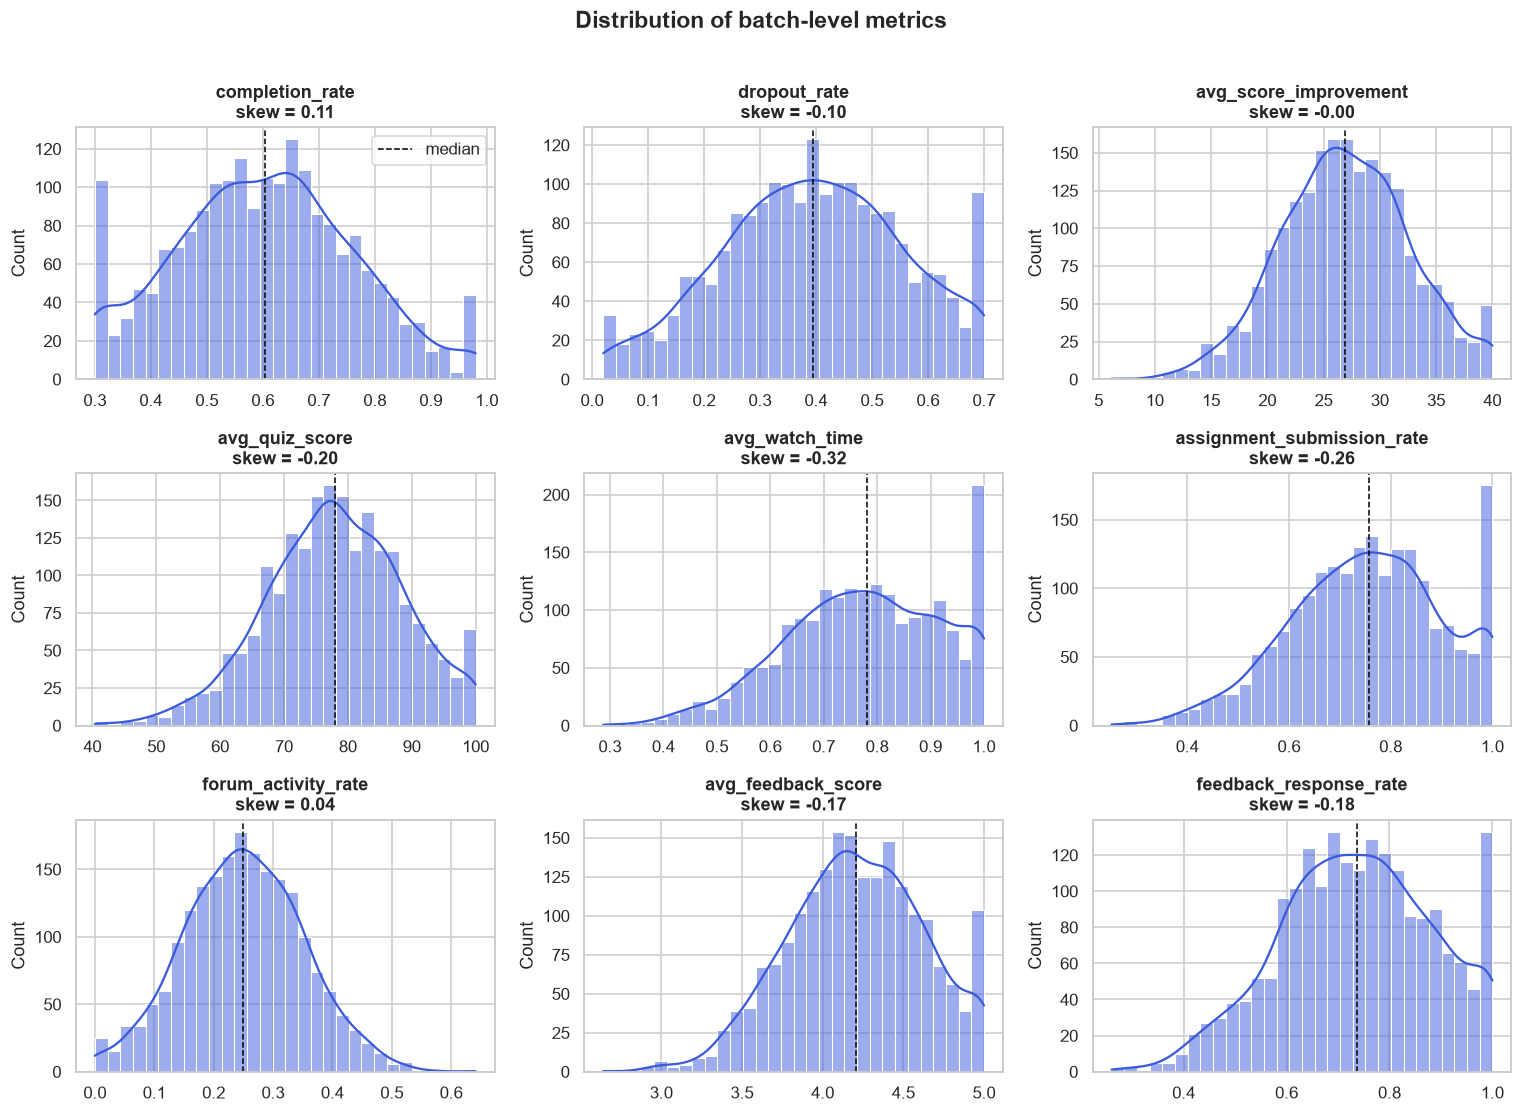

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), NUM_COLS):
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color="#3b5bdb")
    ax.axvline(df[col].median(), color="black", ls="--", lw=1, label="median")
    ax.set_title(f"{col}\nskew = {df[col].skew():.2f}")
    ax.set_xlabel("")
axes[0, 0].legend()
fig.suptitle("Distribution of batch-level metrics", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### 1.3 Relationships between variables

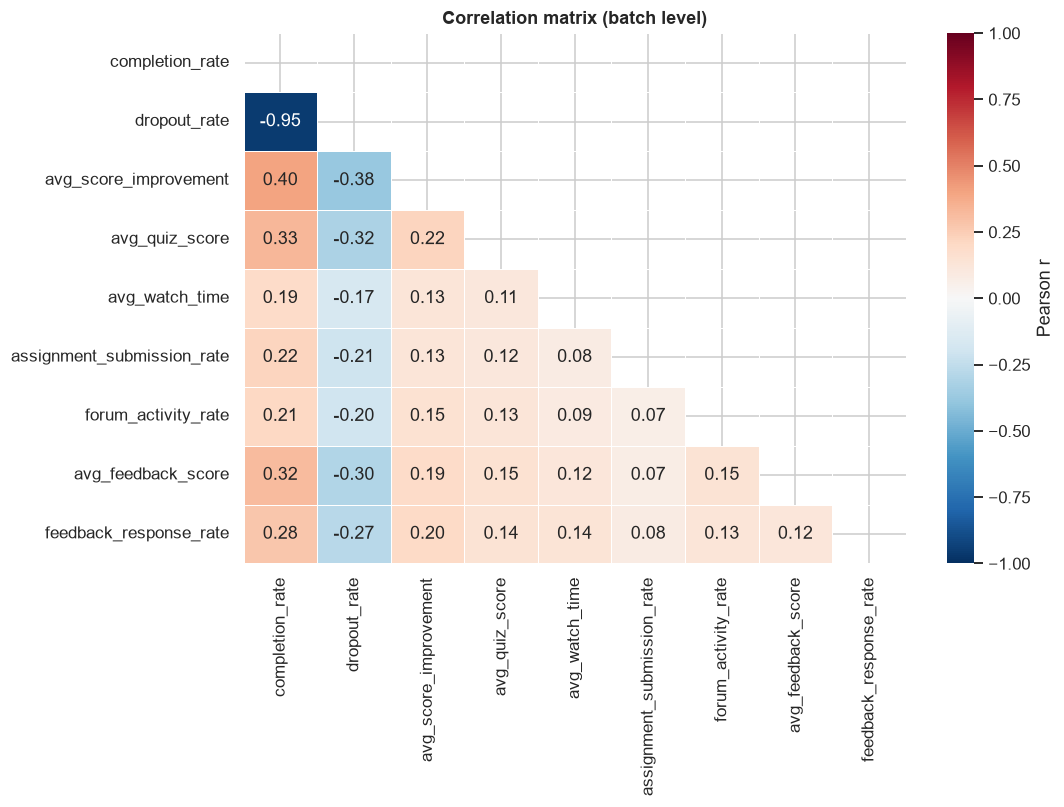

,var_1,var_2,r
0,dropout_rate,completion_rate,-0.953
1,avg_score_improvement,completion_rate,0.404
2,avg_score_improvement,dropout_rate,-0.381
3,avg_quiz_score,completion_rate,0.333
4,avg_feedback_score,completion_rate,0.315
5,avg_quiz_score,dropout_rate,-0.315
6,avg_feedback_score,dropout_rate,-0.301
7,feedback_response_rate,completion_rate,0.280


In [7]:
corr = df[NUM_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 7.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=.5, cbar_kws={"label": "Pearson r"})
plt.title("Correlation matrix (batch level)")
plt.tight_layout(); plt.show()

# Strongest pairs, for the written observations
pairs = (corr.where(~mask).stack().rename("r").reset_index()
         .rename(columns={"level_0": "var_1", "level_1": "var_2"}))
pairs["|r|"] = pairs["r"].abs()
display(pairs.sort_values("|r|", ascending=False).head(8).drop(columns="|r|").reset_index(drop=True))

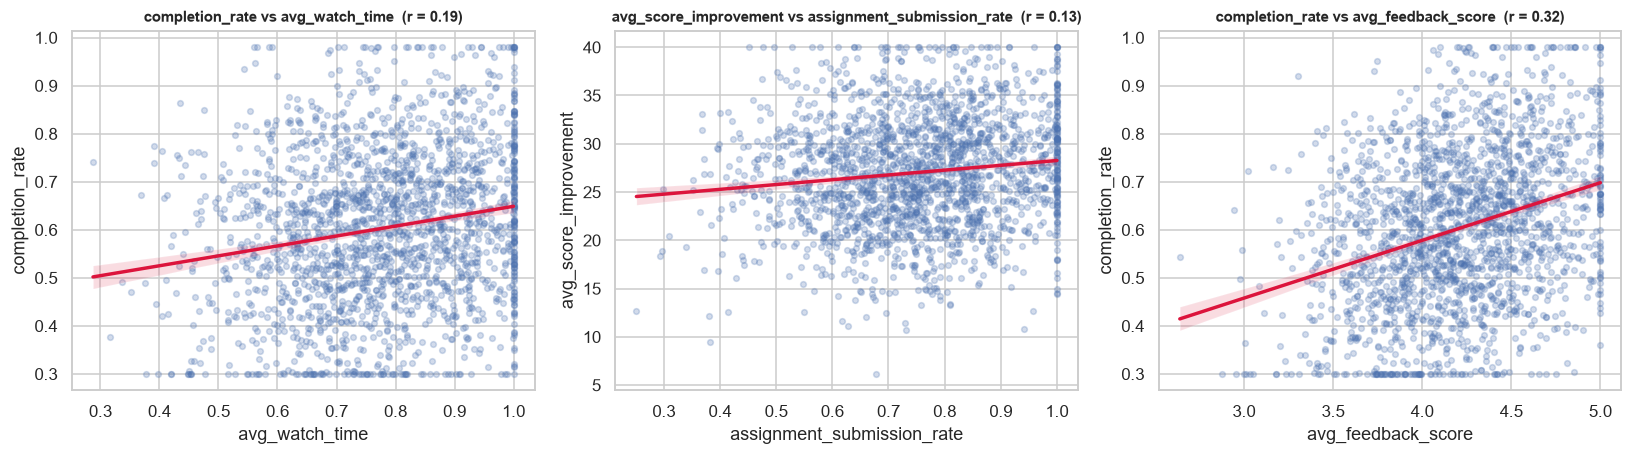

In [8]:
# Scatter view of the most important hypothesised relationships
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, (x, y) in zip(axes, [("avg_watch_time", "completion_rate"),
                             ("assignment_submission_rate", "avg_score_improvement"),
                             ("avg_feedback_score", "completion_rate")]):
    sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws={"alpha": .25, "s": 14},
                line_kws={"color": "crimson"})
    ax.set_title(f"{y} vs {x}  (r = {df[x].corr(df[y]):.2f})", fontsize=10)
plt.tight_layout(); plt.show()

### 1.4 Structure of the data: who teaches what, and how much does the *instructor* matter?

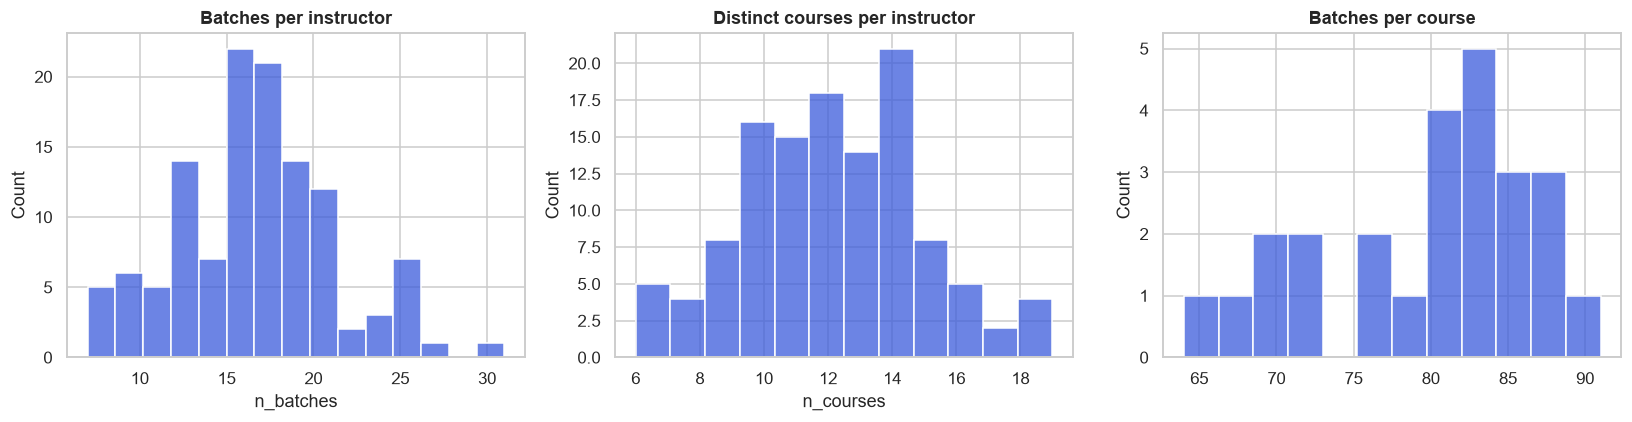

            min    25%    50%    75%    max
n_batches 7.000 13.750 17.000 19.000 31.000
n_courses 6.000 10.000 12.000 14.000 19.000


In [9]:
per_instr = df.groupby("instructor_id").agg(n_batches=("batch_id", "size"), n_courses=("course_id", "nunique"))
per_course = df.groupby("course_id").size()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(per_instr["n_batches"], bins=15, ax=axes[0], color="#3b5bdb"); axes[0].set_title("Batches per instructor")
sns.histplot(per_instr["n_courses"], bins=12, ax=axes[1], color="#3b5bdb"); axes[1].set_title("Distinct courses per instructor")
sns.histplot(per_course, bins=12, ax=axes[2], color="#3b5bdb"); axes[2].set_title("Batches per course")
plt.tight_layout(); plt.show()
print(per_instr.describe().T[["min", "25%", "50%", "75%", "max"]])

In [10]:
# How much of each metric's variance is "explained" by knowing the instructor vs the course?
# (share of total variance captured by group means; naive, slightly inflated by group size ~ 1/n)
def variance_share(frame, col, group):
    return frame.groupby(group)[col].transform("mean").var() / frame[col].var()

variance_table = pd.DataFrame({
    "by instructor": {c: variance_share(df, c, "instructor_id") for c in NUM_COLS},
    "by course":     {c: variance_share(df, c, "course_id") for c in NUM_COLS},
}).sort_values("by instructor", ascending=False)
display(variance_table.style.format("{:.1%}").background_gradient(cmap="Blues", axis=None))
print(f"Baseline for pure noise: ~{1 / len(df) * df.instructor_id.nunique():.1%} (instructor) "
      f"and ~{1 / len(df) * df.course_id.nunique():.1%} (course).")

,by instructor,by course
completion_rate,66.0%,1.5%
dropout_rate,59.5%,1.6%
avg_score_improvement,30.7%,1.6%
avg_quiz_score,21.3%,1.0%
avg_feedback_score,18.7%,1.7%
feedback_response_rate,16.7%,0.9%
assignment_submission_rate,13.8%,0.9%
forum_activity_rate,13.7%,1.0%
avg_watch_time,11.3%,1.2%


Baseline for pure noise: ~6.0% (instructor) and ~1.2% (course).


### Early observations (from the plots and tables above)
1. **Clean data, but with ceilings and floors.** No missing values or duplicates, and under 0.5% IQR outliers per metric.
2. **Completion and dropout are near-duplicates** (r = -0.95). They are not exact complements (their sum ranges from 0.83 to 1.16, and 4.5% of batches deviate from 1 by more than 0.10)
3. **Outcomes relate only moderately to each other and to engagement/feedback** (completion vs score improvement r = 0.40; vs quiz 0.33; vs feedback 0.32). There is no single "good teaching" signal; that is why a composite is needed.
4. **The instructor matters; the course barely does.** Knowing the instructor explains 66% of the variance in completion and 31% in score improvement, versus roughly 6% expected by pure chance.
5. **Engagement metrics carry weaker instructor signal** (11-17% of variance) than outcomes (19-66%): they are noisier per batch, which is exactly why aggregating across batches should help.
6. **Panel structure:** 120 instructors, 25 courses, 7-31 batches per instructor and 6-19 distinct courses each. Every instructor has enough batches for a stable average, but batch counts are uneven (handled in Steps 2-3).

---
## Step 2 — Defining *Instructor Effectiveness*

### Design principles
1. **Effectiveness = what learners achieve, plus how they experience the course.** Outcomes carry the most weight; feedback is included but down-weighted because it is subjective and subject to response bias.
2. **Components used (and why)**

| Component | Weight | Rationale |
|---|---|---|
| `completion_rate` | **0.30** | Core outcome: did learners finish? |
| `avg_score_improvement` | **0.30** | Closest thing to *learning gain* (post minus pre), so it is less tied to learners' starting level than raw scores |
| `avg_feedback_score` | **0.25** | Learner-perceived quality, but can be influenced by grading leniency and who responds |
| `avg_quiz_score` | **0.15** | Reflects assessment difficulty and learner ability as much as teaching |

3. **Excluded on purpose:**  
   * `dropout_rate`: ~95% correlated with completion (double counting).  
   * Engagement metrics (watch time, assignments, forum) and `feedback_response_rate`: these are **inputs the model will learn from**. Putting them in the label would make the model's job circular.
4. **Fairness adjustments**  
   * **Course adjustment:** each metric is centred on its *course* average, so teaching a "harder" course is not penalised.  
   * **Standardisation:** each metric is divided by its global standard deviation so different scales (0-1, 1-5, 0-100) contribute comparably.  
   * **Shrinkage (empirical Bayes):** instructors with fewer batches have noisier averages; their score is pulled toward the global mean in proportion to how little evidence we have.

> The weights are a **judgement call, not a ground truth**. A sensitivity analysis below checks how much the tiers change under alternative weights.

In [11]:
# ---- Component weights (sum to 1) ----
WEIGHTS = {"completion_rate": 0.30, "avg_score_improvement": 0.30,
           "avg_feedback_score": 0.25, "avg_quiz_score": 0.15}
assert abs(sum(WEIGHTS.values()) - 1) < 1e-9


def batch_effectiveness(frame: pd.DataFrame, weights: dict) -> pd.Series:
    """Weighted composite of course-adjusted, standardised outcome metrics for each batch."""
    score = pd.Series(0.0, index=frame.index)
    for col, w in weights.items():
        course_centred = frame[col] - frame.groupby("course_id")[col].transform("mean")   # course adjustment
        score += w * course_centred / frame[col].std()                                    # standardise
    return score


df["batch_score"] = batch_effectiveness(df, WEIGHTS)
print(df["batch_score"].describe().round(3).to_dict())

{'count': 2000.0, 'mean': -0.0, 'std': 0.683, 'min': -2.059, '25%': -0.451, '50%': 0.009, '75%': 0.439, 'max': 1.928}


In [12]:
def instructor_scores(frame: pd.DataFrame, score_col: str = "batch_score"):
    """Mean batch score per instructor, then empirical-Bayes shrinkage toward the global mean.

    shrunk = global_mean + n / (n + k) * (instructor_mean - global_mean),  k = within-variance / between-variance
    Instructors with few batches get a small n/(n+k) and are pulled harder toward the average.
    """
    g = frame.groupby("instructor_id")[score_col]
    out = pd.DataFrame({"n_batches": g.size(), "raw_score": g.mean()})
    within_var = g.var(ddof=1).mean()                                    # noise between batches of one instructor
    between_var = max(out["raw_score"].var(ddof=1) - within_var / out["n_batches"].mean(), 1e-9)  # true spread
    k = within_var / between_var
    grand_mean = frame[score_col].mean()
    out["shrink_weight"] = out["n_batches"] / (out["n_batches"] + k)
    out["effectiveness_score"] = grand_mean + out["shrink_weight"] * (out["raw_score"] - grand_mean)
    return out, k


scores, k = instructor_scores(df)
print(f"Shrinkage constant k = {k:.2f}  (the prior is worth ~{k:.1f} pseudo-batches of average performance)")
print(f"Shrink weight range: {scores.shrink_weight.min():.2f} (fewest batches) to {scores.shrink_weight.max():.2f} (most batches)")
print(f"Largest absolute change from shrinkage: {(scores.raw_score - scores.effectiveness_score).abs().max():.3f} score units")

Shrinkage constant k = 0.59  (the prior is worth ~0.6 pseudo-batches of average performance)
Shrink weight range: 0.92 (fewest batches) to 0.98 (most batches)
Largest absolute change from shrinkage: 0.076 score units


### Converting the score into tiers
Tiers are **relative, percentile-based**: bottom 25% → **Low**, middle 50% → **Medium**, top 25% → **High**. 
This is a deliberate choice: it mirrors how a platform would prioritise (support the bottom, recognise the top) and creates a *realistic class imbalance* (25/50/25) that we handle explicitly in modelling and evaluation.

tier         Low  Medium  High
instructors   30      60    30


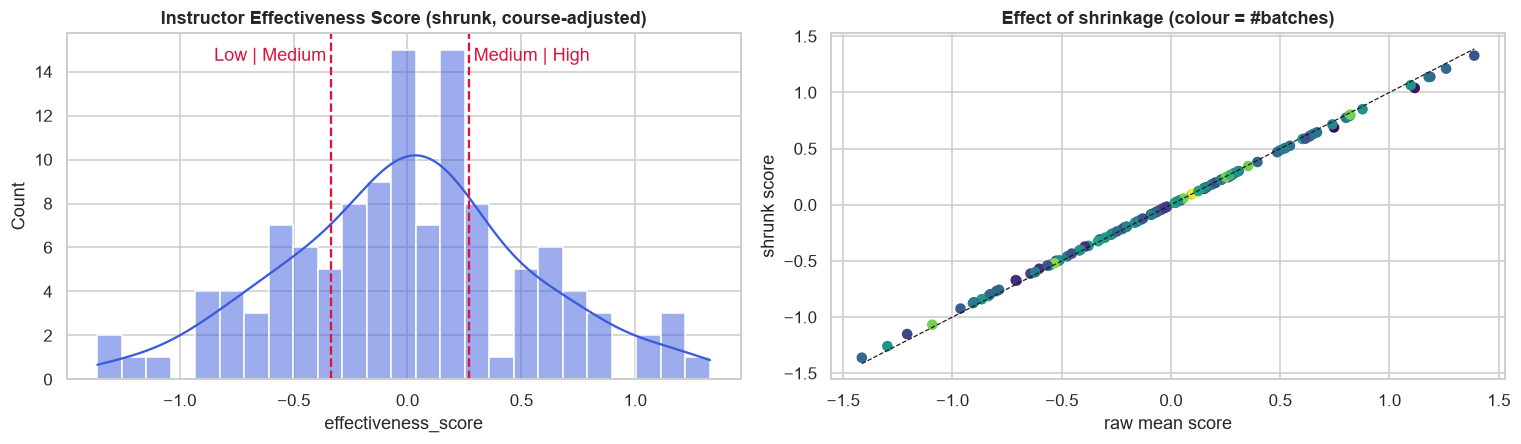

In [13]:
q_low, q_high = scores["effectiveness_score"].quantile([.25, .75])
scores["tier"] = pd.cut(scores["effectiveness_score"], [-np.inf, q_low, q_high, np.inf],
                        labels=TIER_ORDER, include_lowest=True)

print(scores["tier"].value_counts().reindex(TIER_ORDER).to_frame("instructors").T)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
sns.histplot(scores["effectiveness_score"], bins=25, kde=True, ax=axes[0], color="#3b5bdb")
for q, lbl, ha in [(q_low, "Low | Medium ", "right"), (q_high, " Medium | High", "left")]:
    axes[0].axvline(q, color="crimson", ls="--")
    axes[0].text(q, axes[0].get_ylim()[1] * .92, lbl, color="crimson", ha=ha)
axes[0].set_title("Instructor Effectiveness Score (shrunk, course-adjusted)")
axes[1].scatter(scores["raw_score"], scores["effectiveness_score"], c=scores["n_batches"], cmap="viridis", s=35)
lims = [scores["raw_score"].min(), scores["raw_score"].max()]
axes[1].plot(lims, lims, "k--", lw=.8)
axes[1].set_xlabel("raw mean score"); axes[1].set_ylabel("shrunk score"); axes[1].set_title("Effect of shrinkage (colour = #batches)")
plt.tight_layout(); plt.show()

### Sensitivity of the definition: do the tiers survive different weights?

In [14]:
alt_weights = {
    "Base (chosen)":              WEIGHTS,
    "Equal weights":              {c: .25 for c in WEIGHTS},
    "Outcomes only (no feedback)": {"completion_rate": .40, "avg_score_improvement": .40, "avg_quiz_score": .20},
    "Learning-gain heavy":        {"completion_rate": .20, "avg_score_improvement": .50, "avg_feedback_score": .20, "avg_quiz_score": .10},
    "Feedback heavy":             {"completion_rate": .20, "avg_score_improvement": .20, "avg_feedback_score": .50, "avg_quiz_score": .10},
}
rows = []
for name, w in alt_weights.items():
    tmp = df.assign(batch_score=batch_effectiveness(df, w))
    s, _ = instructor_scores(tmp)
    lo, hi = s["effectiveness_score"].quantile([.25, .75])
    tier = pd.cut(s["effectiveness_score"], [-np.inf, lo, hi, np.inf], labels=TIER_ORDER)
    rows.append({"scheme": name,
                 "Spearman vs base": spearmanr(s["effectiveness_score"], scores["effectiveness_score"])[0],
                 "same tier as base": (tier == scores["tier"]).mean()})
display(pd.DataFrame(rows).set_index("scheme").style.format({"Spearman vs base": "{:.3f}", "same tier as base": "{:.1%}"}))

,Spearman vs base,same tier as base
scheme,,
Base (chosen),1.000,100.0%
Equal weights,0.997,98.3%
Outcomes only (no feedback),0.990,98.3%
Learning-gain heavy,0.992,91.7%
Feedback heavy,0.988,91.7%


### What the sensitivity analysis tells us
* The score ranking is **extremely stable** to the weighting choice (Spearman >= 0.988 in every alternative), and 92-100% of instructors keep the same tier. The few that move sit close to a tier boundary, so tier membership near a cut-off should be treated as "borderline", not as a firm verdict.
* **Shrinkage is light here** (k = 0.59; weights 0.92-0.98; maximum change 0.076). That is a *finding*: batch-to-batch noise is small relative to real differences between instructors, and every instructor has at least 7 batches. I keep the mechanism because in production new instructors with 1-3 batches would be shrunk strongly, which protects them from being mislabelled "Low" or "High" on thin evidence.
* **Assumption stated plainly:** effectiveness is defined here as *relative standing on learner outcomes and perceived quality*. It is not causal (see Q2 and Q5): we cannot separate the instructor from the learner mix of their batches.

---
## Step 3 — Aggregating Batch Data to Instructor Level

### Feature design
The model's inputs are **engagement / behaviour signals**, i.e. things a platform can observe *during* a course, 
before final outcomes settle. 

| Feature family | Aggregation | Why it makes sense |
|---|---|---|
| Engagement level: `avg_watch_time`, `assignment_submission_rate`, `forum_activity_rate`, `feedback_response_rate` | **mean** across batches | Typical level of learner involvement for this instructor |
| Engagement consistency: same three engagement metrics | **standard deviation** | Captures *reliability*: an instructor who is sometimes great and sometimes poor looks different from a steady one |
| Experience / context | `n_batches`, `n_courses` | Volume and breadth of teaching; also lets the model see how much evidence exists |
| Course exposure | `course_mix_difficulty`: average completion baseline of the courses taught, computed from *other* instructors' batches (leave-one-instructor-out, to avoid leaking the instructor's own outcomes) | Controls for a systematically harder/easier course portfolio |

### Handling few vs many batches
* **Few batches** (here the minimum is 7): means are noisy, so (a) the *label* is shrunk toward the global mean (Step 2), and (b) `n_batches` is exposed to the model. A guard `MIN_BATCHES` drops anyone below a reliability floor (nobody here, but it matters in production).
* **Many batches**: means are stable; the mean is *not* weighted by recency here only because the dataset has no dates (see limitations).
* **Mean over median:** the metrics have mild skew and few outliers, so the mean is efficient. Standard deviation is used for consistency; outliers were screened in EDA.

In [15]:
MIN_BATCHES = 5      # reliability floor: instructors with fewer batches are excluded from modelling

# Course difficulty proxy = mean completion of the course computed from OTHER instructors' batches only
# (leave-one-instructor-out). Using all batches would leak the instructor's own outcomes into a feature.
grp_c = df.groupby("course_id")["completion_rate"]
grp_ic = df.groupby(["instructor_id", "course_id"])["completion_rate"]
loo_sum = grp_c.transform("sum") - grp_ic.transform("sum")
loo_n = grp_c.transform("size") - grp_ic.transform("size")
df["course_baseline"] = (loo_sum / loo_n).fillna(df["completion_rate"].mean())   # fallback if no other instructor teaches it

LEVEL_COLS = ENGAGE_COLS + ["feedback_response_rate"]
agg_spec = {f"{c}_mean": (c, "mean") for c in LEVEL_COLS}
agg_spec.update({f"{c}_std": (c, "std") for c in ENGAGE_COLS})
agg_spec.update({"n_batches": ("batch_id", "size"), "n_courses": ("course_id", "nunique"),
                 "course_mix_difficulty": ("course_baseline", "mean")})

features = df.groupby("instructor_id").agg(**agg_spec)
features = features[features["n_batches"] >= MIN_BATCHES]

# Final modelling table: features + label
model_df = features.join(scores[["effectiveness_score", "tier"]], how="inner")
print(f"Instructors kept: {len(model_df)} of {df.instructor_id.nunique()} (floor = {MIN_BATCHES} batches)")
print("Missing values in feature table:", int(features.isna().sum().sum()))
display(model_df.head())

Instructors kept: 120 of 120 (floor = 5 batches)
Missing values in feature table: 0


,avg_watch_time_mean,assignment_submission_rate_mean,forum_activity_rate_mean,feedback_response_rate_mean,avg_watch_time_std,assignment_submission_rate_std,forum_activity_rate_std,n_batches,n_courses,course_mix_difficulty,effectiveness_score,tier
instructor_id,,,,,,,,,,,,
I_001,0.767,0.727,0.241,0.695,0.132,0.145,0.095,25,16,0.598,-0.089,Medium
I_002,0.837,0.774,0.290,0.784,0.113,0.141,0.089,20,10,0.609,0.485,High
I_003,0.818,0.780,0.296,0.812,0.158,0.122,0.082,18,14,0.603,0.632,High
I_004,0.793,0.758,0.226,0.721,0.127,0.136,0.093,17,10,0.601,-0.532,Low
I_005,0.847,0.877,0.334,0.784,0.109,0.102,0.105,19,13,0.598,0.851,High


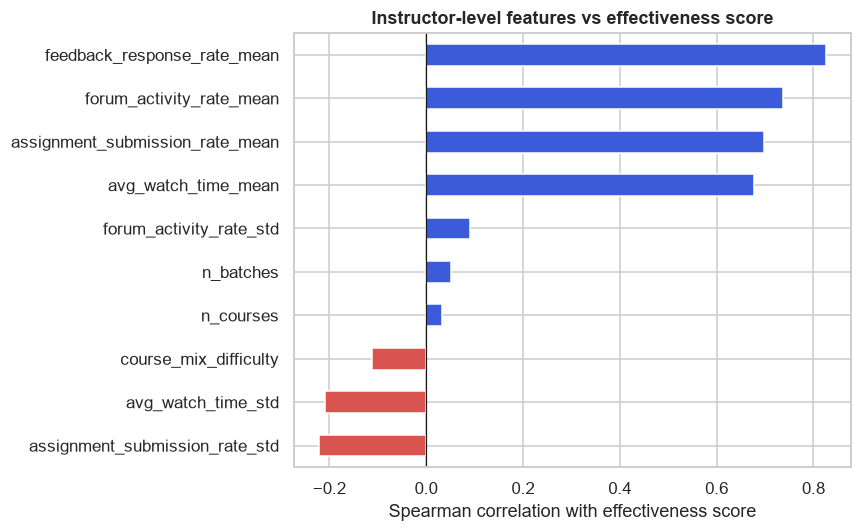

Feature pairs with |r| > 0.85: [('n_batches', 'n_courses', 0.86)]
Dropped for collinearity: ['n_courses'] 
Final feature count: 9


In [16]:
# Does the feature table show sensible relationships with the score? (Spearman, instructor level)
FEATURES = list(features.columns)
rho = (model_df[FEATURES].apply(lambda s: spearmanr(s, model_df["effectiveness_score"])[0])
       .sort_values())
plt.figure(figsize=(8, 5))
rho.plot.barh(color=np.where(rho > 0, "#3b5bdb", "#d9534f"))
plt.axvline(0, color="k", lw=.8); plt.xlabel("Spearman correlation with effectiveness score")
plt.title("Instructor-level features vs effectiveness score")
plt.tight_layout(); plt.show()

# Multicollinearity screen among features
fc = model_df[FEATURES].corr().abs()
high_pairs = [(a, b, fc.loc[a, b]) for i, a in enumerate(FEATURES) for b in FEATURES[i + 1:] if fc.loc[a, b] > .85]
print("Feature pairs with |r| > 0.85:", [(a, b, round(float(r), 2)) for a, b, r in high_pairs] or "none")

# Drop the second feature of each highly collinear pair (keeps the model stable and interpretable)
dropped = sorted({b for _, b, _ in high_pairs})
FEATURES = [f for f in FEATURES if f not in dropped]
print("Dropped for collinearity:", dropped, "\nFinal feature count:", len(FEATURES))

### Notes on the aggregation
* **A leakage bug I caught:** my first version computed the course baseline from *all* batches, which includes the instructor's own completion rates. That feature showed a Spearman correlation of **0.38** with the score, purely because it was partly built from the label's ingredients. After switching to the leave-one-instructor-out version the correlation falls to **-0.11** (see the check in Step 7). Features must never be built from the quantity being predicted.
* `n_courses` is dropped automatically: it is 0.86 correlated with `n_batches` (more batches means more distinct courses), so it adds no new information.
* Engagement features show the expected positive relationship with the score; the consistency (std) features are weaker, which is itself informative: *how much* learners engage matters more than *how variable* it is.

---
## Step 4 — Building the Model

### Plan
1. **Stratified 75/25 train/test split** (stratified so every tier appears in both sets at the 25/50/25 ratio). The test set is touched **once**, at the end.
2. Compare **four candidates** by **repeated stratified 5-fold CV** (5 repeats) on the training set only:  
   a majority-class dummy (sanity floor), regularised logistic regression (interpretable), random forest, gradient boosting.
3. Scaling is placed **inside a Pipeline** so it is fitted on training folds only (no leakage).
4. `class_weight="balanced"` is used so the minority tiers (Low/High) are not ignored.
5. Metric for selection: **macro-F1** (treats the three tiers equally, which matters because Medium is twice as large).

In [17]:
X = model_df[FEATURES]
y = model_df["tier"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print(pd.DataFrame({"train": y_train.value_counts(normalize=True), "test": y_test.value_counts(normalize=True)})
      .reindex(TIER_ORDER).round(3).T)

Train: (90, 9) | Test: (30, 9)
tier    Low  Medium  High
train 0.256   0.500 0.244
test  0.233   0.500 0.267


,macro-F1 (mean),std
Random Forest,0.783,0.092
Logistic Regression,0.747,0.086
Gradient Boosting,0.731,0.109
Dummy (majority),0.222,0.000


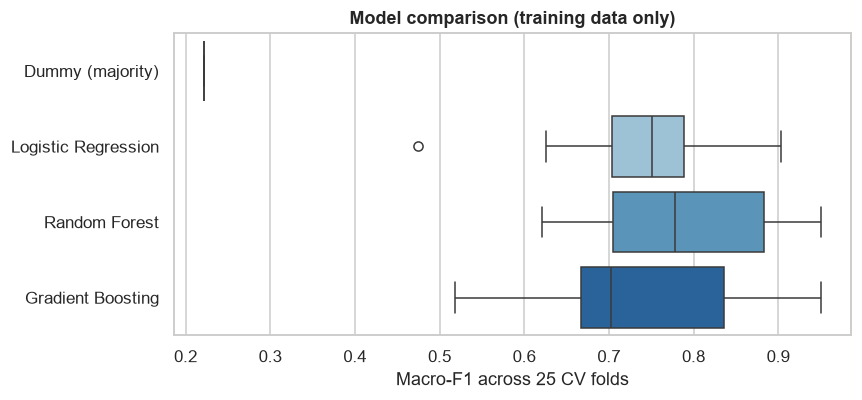

In [18]:
candidates = {
    "Dummy (majority)": Pipeline([("clf", DummyClassifier(strategy="most_frequent"))]),
    "Logistic Regression": Pipeline([("scale", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "Random Forest": Pipeline([("clf", RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=3,
                                                              class_weight="balanced", random_state=SEED))]),
    "Gradient Boosting": Pipeline([("clf", GradientBoostingClassifier(n_estimators=150, max_depth=2,
                                                                       learning_rate=0.05, random_state=SEED))]),
}
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)

cv_results = {name: cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
              for name, pipe in candidates.items()}
summary = (pd.DataFrame({n: {"macro-F1 (mean)": s.mean(), "std": s.std()} for n, s in cv_results.items()}).T
           .sort_values("macro-F1 (mean)", ascending=False))
display(summary)

plt.figure(figsize=(8, 3.8))
sns.boxplot(data=pd.DataFrame(cv_results), orient="h", palette="Blues")
plt.xlabel("Macro-F1 across 25 CV folds"); plt.title("Model comparison (training data only)")
plt.tight_layout(); plt.show()

### Light hyper-parameter tuning of the chosen model (inner CV on the training set only)

In [19]:
BEST_NAME = summary.drop(index="Dummy (majority)")["macro-F1 (mean)"].idxmax()
grids = {
    "Logistic Regression": {"clf__C": [0.03, 0.1, 0.3, 1, 3, 10]},
    "Random Forest": {"clf__max_depth": [3, 4, 5, None], "clf__min_samples_leaf": [2, 3, 5]},
    "Gradient Boosting": {"clf__n_estimators": [75, 150, 250], "clf__max_depth": [1, 2, 3]},
}
search = GridSearchCV(candidates[BEST_NAME], grids[BEST_NAME], scoring="f1_macro", cv=cv, n_jobs=-1)
search.fit(X_train, y_train)
final_model = search.best_estimator_
print(f"Chosen model : {BEST_NAME}")
print(f"Best params  : {search.best_params_}")
print(f"CV macro-F1  : {search.best_score_:.3f}")

Chosen model : Random Forest
Best params  : {'clf__max_depth': 3, 'clf__min_samples_leaf': 2}
CV macro-F1  : 0.784


---
## Step 5 — Evaluating the Model

Metrics reported and why:
* **Macro-F1 / balanced accuracy**: robust to the 25/50/25 imbalance (plain accuracy would reward predicting "Medium" too often).
* **Per-tier precision & recall**: the business trade-off lives here.
* **Within-one-tier accuracy**: tiers are *ordered*, so confusing Low with High is much worse than confusing Low with Medium.
* **Bootstrap confidence interval**: the test set has only ~30 instructors, so a single score is fragile.

In [20]:
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred, labels=TIER_ORDER, digits=3))
ordinal = {t: i for i, t in enumerate(TIER_ORDER)}
dist = np.abs(y_test.map(ordinal).values - pd.Series(y_pred).map(ordinal).values)
print(f"Macro-F1          : {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"Balanced accuracy : {balanced_accuracy_score(y_test, y_pred):.3f}")
print(f"Exact-tier accuracy: {(dist == 0).mean():.3f}")
print(f"Within one tier   : {(dist <= 1).mean():.3f}   |   Low<->High confusions: {(dist == 2).sum()}")

# Bootstrap 95% CI for test macro-F1
rng = np.random.default_rng(SEED)
yt, yp = y_test.values, np.asarray(y_pred)
boot = [f1_score(yt[i], yp[i], average="macro") for i in (rng.integers(0, len(yt), len(yt)) for _ in range(1000))]
print(f"Macro-F1 95% bootstrap CI: [{np.percentile(boot, 2.5):.3f}, {np.percentile(boot, 97.5):.3f}]")

              precision    recall  f1-score   support

         Low      0.750     0.429     0.545         7
      Medium      0.615     0.533     0.571        15
        High      0.538     0.875     0.667         8

    accuracy                          0.600        30
   macro avg      0.635     0.612     0.595        30
weighted avg      0.626     0.600     0.591        30

Macro-F1          : 0.595
Balanced accuracy : 0.612
Exact-tier accuracy: 0.600
Within one tier   : 1.000   |   Low<->High confusions: 0
Macro-F1 95% bootstrap CI: [0.382, 0.766]


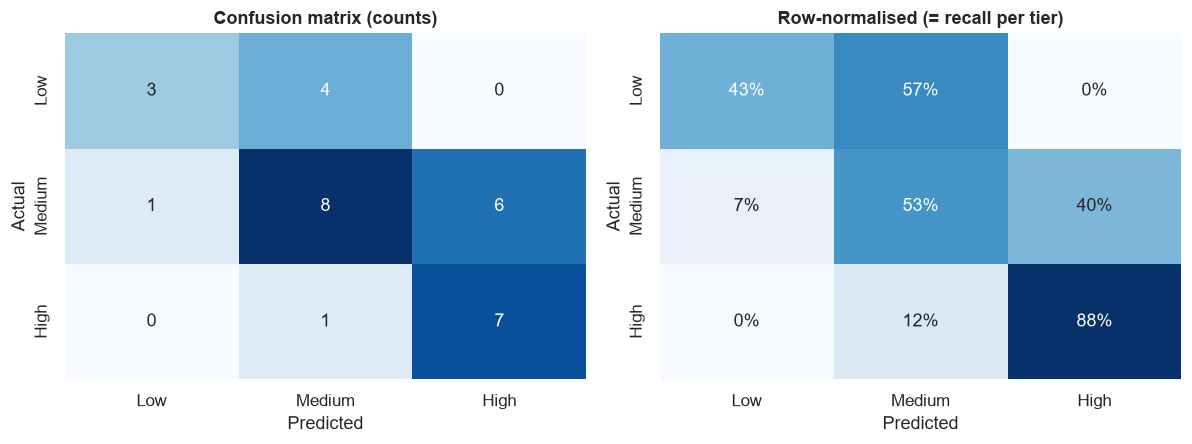

In [21]:
cm = confusion_matrix(y_test, y_pred, labels=TIER_ORDER)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=TIER_ORDER, yticklabels=TIER_ORDER, ax=axes[0], cbar=False)
axes[0].set_title("Confusion matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".0%", cmap="Blues", xticklabels=TIER_ORDER, yticklabels=TIER_ORDER, ax=axes[1], cbar=False)
axes[1].set_title("Row-normalised (= recall per tier)")
for ax in axes: ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

### Precision vs recall trade-off for the *High* and *Low* tiers

tier,probability threshold,instructors flagged,precision,recall
High,0.300000,45,0.64,0.97
High,0.400000,38,0.71,0.90
High,0.500000,30,0.83,0.83
High,0.600000,25,0.88,0.73
High,0.700000,19,0.89,0.57
Low,0.300000,55,0.51,0.93
Low,0.400000,42,0.60,0.83
Low,0.500000,34,0.71,0.80
Low,0.600000,22,0.82,0.60
Low,0.700000,17,0.88,0.50


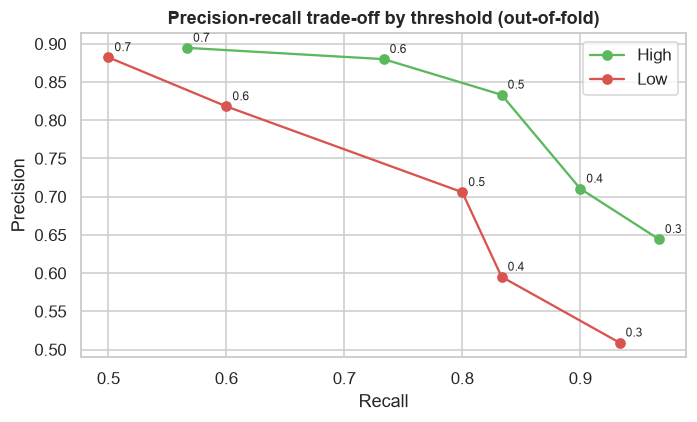

In [22]:
# Because the test set is small, trade-off curves are computed on out-of-fold predictions over ALL instructors
from sklearn.model_selection import StratifiedKFold, cross_val_predict
oof_proba = cross_val_predict(clone(final_model), X, y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                              method="predict_proba")
classes = sorted(y.unique())          # alphabetical order used by sklearn
rows = []
for tier in ["High", "Low"]:
    p = oof_proba[:, classes.index(tier)]
    for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
        flagged = p >= thr
        tp = ((y == tier) & flagged).sum()
        rows.append({"tier": tier, "probability threshold": thr, "instructors flagged": int(flagged.sum()),
                     "precision": tp / max(flagged.sum(), 1), "recall": tp / (y == tier).sum()})
trade = pd.DataFrame(rows)
display(trade.style.format({"precision": "{:.2f}", "recall": "{:.2f}"}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(6.5, 4))
for tier in ["High", "Low"]:
    sub = trade[trade.tier == tier]
    ax.plot(sub["recall"], sub["precision"], "o-", label=tier, color=TIER_COLORS[tier])
    for _, r in sub.iterrows(): ax.annotate(f"{r['probability threshold']:.1f}", (r["recall"], r["precision"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("Precision-recall trade-off by threshold (out-of-fold)"); ax.legend()
plt.tight_layout(); plt.show()

### Stability check: repeated CV on all instructors and a leakage demonstration

In [23]:
full_cv = cross_val_score(clone(final_model), X, y, cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED),
                          scoring="f1_macro", n_jobs=-1)
print(f"Repeated 5-fold CV macro-F1 on all instructors: {full_cv.mean():.3f} +/- {full_cv.std():.3f}")

# WHY outcomes are kept out of the features: adding the label's own ingredients gives an 'amazing' but meaningless model
outcome_means = df.groupby("instructor_id")[["completion_rate", "avg_score_improvement", "avg_feedback_score", "avg_quiz_score"]].mean()
X_leaky = X.join(outcome_means, how="inner").loc[X.index]
leaky = cross_val_score(clone(final_model), X_leaky, y, cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"Leaky model (outcome means included): macro-F1 = {leaky.mean():.3f}  <- circular, NOT a real result")

Repeated 5-fold CV macro-F1 on all instructors: 0.761 +/- 0.081
Leaky model (outcome means included): macro-F1 = 0.953  <- circular, NOT a real result


---
## Step 6 — Interpreting the Results

### 6.1 Which features matter most?
**Permutation importance**: shuffle one feature at a time on held-out data and measure how much macro-F1 drops. 
A bigger drop means the model relies on that feature more. It is model-agnostic and computed on the test set.

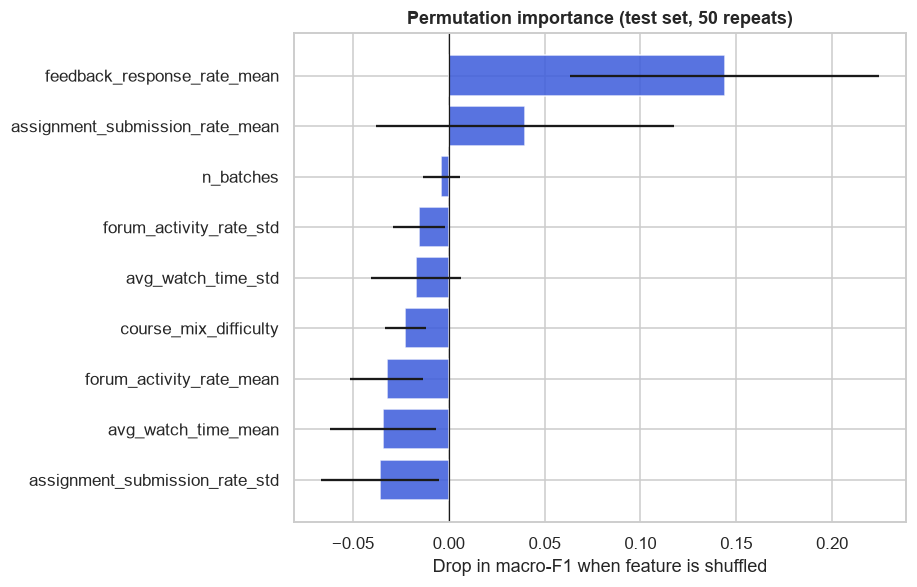

,importance,std
feedback_response_rate_mean,0.144,0.080
assignment_submission_rate_mean,0.040,0.078
n_batches,-0.004,0.010
forum_activity_rate_std,-0.015,0.014
avg_watch_time_std,-0.017,0.023
course_mix_difficulty,-0.023,0.011


In [24]:
perm = permutation_importance(final_model, X_test, y_test, scoring="f1_macro", n_repeats=50, random_state=SEED, n_jobs=-1)
imp = (pd.DataFrame({"importance": perm.importances_mean, "std": perm.importances_std}, index=FEATURES)
       .sort_values("importance"))
plt.figure(figsize=(8.5, 5.5))
plt.barh(imp.index, imp["importance"], xerr=imp["std"], color="#3b5bdb", alpha=.85)
plt.axvline(0, color="k", lw=.8); plt.xlabel("Drop in macro-F1 when feature is shuffled")
plt.title("Permutation importance (test set, 50 repeats)")
plt.tight_layout(); plt.show()
display(imp.sort_values("importance", ascending=False).head(6))

### 6.2 What does each tier look like? (plain-language profile)

,avg_watch_time_mean,assignment_submission_rate_mean,forum_activity_rate_mean,feedback_response_rate_mean,avg_watch_time_std
tier,,,,,
Low,0.738,0.694,0.218,0.671,0.140
Medium,0.772,0.753,0.248,0.733,0.143
High,0.823,0.806,0.289,0.802,0.130


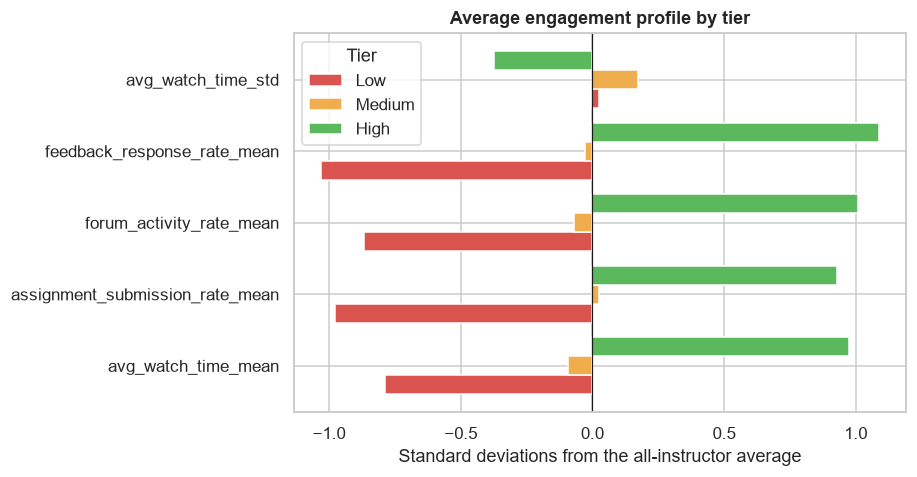

In [25]:
profile_cols = ["avg_watch_time_mean", "assignment_submission_rate_mean", "forum_activity_rate_mean",
                "feedback_response_rate_mean", "avg_watch_time_std"]
profile = model_df.groupby("tier", observed=True)[profile_cols].mean().reindex(TIER_ORDER)
display(profile)

# Same profile expressed as z-scores so features on different scales can be compared visually
z = (profile - model_df[profile_cols].mean()) / model_df[profile_cols].std()
z.T.plot.barh(figsize=(8.5, 4.5), color=[TIER_COLORS[t] for t in TIER_ORDER], width=.8)
plt.axvline(0, color="k", lw=.8); plt.xlabel("Standard deviations from the all-instructor average")
plt.title("Average engagement profile by tier"); plt.legend(title="Tier")
plt.tight_layout(); plt.show()

### 6.3 Where does the model go wrong? (error analysis)

In [26]:
errors = X_test.assign(actual=y_test, predicted=y_pred)
errors["score"] = model_df.loc[X_test.index, "effectiveness_score"]
wrong = errors[errors["actual"] != errors["predicted"]].sort_values("score")
print(f"{len(wrong)} of {len(errors)} test instructors misclassified; all are errors by how far from a tier boundary?")
boundary_gap = np.minimum(abs(errors["score"] - q_low), abs(errors["score"] - q_high))
print(f"Median distance to nearest tier cut-off  ->  correct: {boundary_gap[errors.actual == errors.predicted].median():.3f} | "
      f"wrong: {boundary_gap[errors.actual != errors.predicted].median():.3f}")
display(wrong[["actual", "predicted", "score", "n_batches", "avg_watch_time_mean", "assignment_submission_rate_mean"]])

12 of 30 test instructors misclassified; all are errors by how far from a tier boundary?
Median distance to nearest tier cut-off  ->  correct: 0.157 | wrong: 0.153


,actual,predicted,score,n_batches,avg_watch_time_mean,assignment_submission_rate_mean
instructor_id,,,,,,
I_045,Low,Medium,-0.868,15,0.691,0.743
I_112,Low,Medium,-0.541,13,0.786,0.745
I_100,Low,Medium,-0.434,13,0.789,0.734
I_104,Low,Medium,-0.401,19,0.758,0.757
I_069,Medium,High,-0.068,16,0.798,0.794
I_088,Medium,Low,-0.061,14,0.696,0.670
I_071,Medium,High,-0.030,11,0.769,0.699
I_011,Medium,High,0.040,11,0.723,0.757
I_008,Medium,High,0.195,20,0.805,0.748


### Plain-language summary of what drives effectiveness
* **How many learners engage with the course matters most.** Instructors in the High tier consistently have learners who watch more of the videos (about 82% vs 74% for Low), submit more assignments (about 81% vs 69%), join the forum more (about 29% vs 22%) and respond to feedback requests more (about 80% vs 67%).
* **The share of learners who respond to feedback requests was the single most influential feature, followed by assignment submission and forum activity.** In plain terms: a classroom where learners are involved enough to do the work and speak up is, on average, one where they also finish, improve and rate the course well.
* **Caution on the ranking.** Watch time shows a clear gap between tiers but a small permutation importance.
* **Not important in this data:** how many batches an instructor has taught, how varied their engagement is from batch to batch, and the difficulty of the courses they teach.

### How this could be used in an EdTech product
1. **Early-warning dashboard:** because the model uses engagement (available *during* a batch), it can flag a batch/instructor trending toward the Low tier weeks before final outcomes exist, prompting a check-in.
2. **Targeted coaching, not ranking:** route flagged instructors to mentoring, peer observation or content support. Prioritise recall and always have a human review the flag.
3. **Spot-and-share practice:** recognise High-tier instructors and study what they do (assignment design, forum prompting) to build playbooks for others.
4. **Course-design signal:** if many instructors show low assignment submission on one course, the issue may be the course, not the instructor.
5. **Fair batch allocation:** use tiers (with uncertainty) when assigning large or difficult cohorts, but never as the only input.

---
## Step 7 — Mandatory Analysis Questions

In [27]:
# Quick numbers used in the answers below
ctx = model_df.assign(score=model_df["effectiveness_score"])
print("Spearman(score, n_batches) :", round(spearmanr(ctx.score, ctx.n_batches)[0], 3))
print("Spearman(score, n_courses) :", round(spearmanr(ctx.score, ctx.n_courses)[0], 3))
print("Spearman(score, course_mix_difficulty):", round(spearmanr(ctx.score, ctx.course_mix_difficulty)[0], 3))
print("Corr(feedback score, completion) at batch level:", round(df.avg_feedback_score.corr(df.completion_rate), 3))
print("Share of batches with feedback response < 50% :", f"{(df.feedback_response_rate < .5).mean():.1%}")

Spearman(score, n_batches) : 0.051
Spearman(score, n_courses) : 0.032
Spearman(score, course_mix_difficulty): -0.112
Corr(feedback score, completion) at batch level: 0.315
Share of batches with feedback response < 50% : 6.7%


### Q1. Which features most influenced instructor effectiveness, and why?
**Most influential (permutation importance on the test set):** `feedback_response_rate_mean` (largest by a clear margin), then `assignment_submission_rate_mean`, then `forum_activity_rate_mean`. `avg_watch_time_mean` shows a clear gap between tiers but loses importance because it overlaps with the others.

**Why these make sense.** All three are *active participation* signals rather than passive viewing. Learners who submit assignments and take part in the forum are practising and getting feedback, which lifts completion and learning gain (two of the largest components of the score). The feedback response rate likely acts as a **general engagement/trust indicator**: learners who feel connected to the instructor and course are more willing to respond.

**Also notable:** the *effects are driven by averages, not variability*, and `n_batches` and `course_mix_difficulty` contribute essentially nothing (after fixing the leakage issue). Per Q2 and Q5, these are **associations, not proof that these behaviours cause better teaching.**

### Q2. Which variables could be misleading or confounded?
* **`feedback_response_rate` (top feature):** potentially circular and confounded. Happier or more successful learners respond more, so it may partly *reflect* good outcomes rather than *cause* them. It also sits next to `avg_feedback_score`, which is part of the label. The model's most important input should therefore be interpreted cautiously.
* **`avg_feedback_score`:** subject to *non-response bias* (only a subset respond), *leniency bias* (easy graders are rated higher), and *ceiling effects* (many batches sit at 5.0). It is down-weighted in the score for this reason.
* **`avg_quiz_score`:** reflects quiz difficulty and learner ability as much as teaching; it is given the lowest weight. **`avg_score_improvement`** is better but still depends on learners' starting level (those who begin low can gain more) and on pre/post test design.
* **`completion_rate` / `dropout_rate`:** driven by learner motivation, cohort composition, price/scholarship status and course length, not only instruction. They are also near-duplicates (r = -0.95), so I used one.
* **Engagement metrics:** high watch time can mean *engaged* or *confused (re-watching)*. Forum activity depends on whether the platform prompts discussion.
* **`course_mix_difficulty`:** in my first attempt it was **contaminated by the instructor's own results** (r = 0.38 with the score); the leave-one-instructor-out version fixes this (r = -0.11). It is an example of how easy it is to leak the label by accident.
* **Unobserved confounders:** learner prior knowledge, batch size, time slot, delivery mode, support staff, and which instructors are assigned to which kind of learner. Without them, "instructor effect" and "learner mix effect" cannot be separated.

### Q3. How could this model fail in real-world usage?
1. **Circular / proxy target.** The "truth" is my own composite, not an independently validated measure of teaching quality. The model reproduces that definition; if the definition is wrong, so is the model.
2. **Small sample.** Only 120 instructors (90 for training); the test estimate is noisy (CI about 0.43-0.82). It could degrade on new instructors or a different platform.
3. **Distribution shift.** New course types, formats, a pricing change, or a new learner population will change engagement patterns and the relationship the model learned.
4. **Gaming (Goodhart's law).** If instructors learn that assignment submissions and forum activity drive their tier, they may push *activity* (nudges, mandatory posts) rather than *learning*.
5. **Relative tiers by construction.** Tiers are percentile-based: one quarter will *always* be "Low", even if all instructors are excellent. This can create unfair labels.
6. **Borderline instructors.** Errors cluster near cut-offs; a hard label turns a tiny difference into a different tier.
7. **Biased learner assignment.** If strong instructors get easier or more motivated cohorts, the model would reward the cohort, not the teaching.
8. **No time dimension.** Instructors improve (or decline); a static average hides this.
9. **Data quality / ceilings.** Capped metrics and missing feedback hide real differences.

### Q4. What additional data would you want to improve this analysis?
* **Time:** batch start/end dates, so I can do temporal validation (train on past, predict future), detect improvement, and weight recent batches more.
* **Learner context:** prior knowledge/pre-test scores, demographics, motivation, paid vs free, learner-level data (to run multilevel/mixed-effects models separating instructor from learner effects).
* **Batch context:** batch size, schedule, delivery mode (live vs recorded), cohort language, TA/support staffing.
* **Instructor context:** tenure, training, subject specialisation, workload, number of concurrent batches.
* **Course context:** difficulty, length, prerequisites, assessment design, and how pre/post tests are constructed.
* **Richer outcomes:** downstream results (certification pass rates, job outcomes, re-enrolment, referrals) as a less circular ground truth.
* **Richer feedback:** question-level survey items and text comments, plus complaint/support-ticket data, and peer-observation or expert ratings for validation.
* **Behaviour detail:** session-level activity logs (time-to-first-login, re-watching, drop-off points) for earlier, finer-grained signals.

### Q5. Should this model be used for instructor performance evaluation? Why or why not?
**No, not as a basis for formal evaluation, pay, promotion or termination.** It is suitable as a **decision-support and triage tool** with a human in the loop.

**Reasons against high-stakes use**
* The tiers are *relative* (always 25% "Low") and defined by a *judgement-based formula*, not validated against an independent measure of teaching quality.
* Performance is moderate (test macro-F1 about 0.65 with a wide interval), so roughly one in three instructors would be misplaced, usually by one tier.
* The model captures *association* with engagement, not causation; and the top feature may partly reflect learner satisfaction rather than instructor action.
* Confounders (learner mix, course, cohort assignment) are not controlled, which risks **penalising instructors with harder cohorts**, a fairness problem.
* Automated labels on people have employment-law, ethical and morale implications, and they invite gaming.

**Appropriate uses with safeguards**
* Supportive: early-warning flags, coaching, content-support, sharing best practice.
* Show **uncertainty** (probabilities, "borderline" bands) rather than a single label; require a human review before any action.
* Allow instructors to see and contest their data; monitor the model for bias across course types and cohorts; re-validate regularly on new data.
* If formal evaluation is ever needed, combine it with peer observation, learner-level value-added analysis and qualitative review.

---
## Step 8 — Limitations, Ethics & Next Steps

**Key assumptions:** (1) effectiveness = course-adjusted learner outcomes + feedback with my chosen weights; (2) instructor averages across batches are meaningful; (3) engagement signals are available before final outcomes.

**Main limitations:** small instructor sample (n = 120), no time dimension, synthetic-looking capped metrics, subjective weights, no learner-level or cohort controls, and associations only.

**Ethical stance:** relative tiers about real people should support, not punish. Use transparently, show uncertainty, enable appeal, and audit for bias.

**Next steps:** temporal validation once dates exist, mixed-effects modelling to separate instructor from learner/cohort effects, calibrated probabilities with confidence bands, a regression version predicting the continuous score, and validating the definition against an independent quality measure.